In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import sys
sys.path.append('.')
from Data.dataset_v2 import PixelClusterDataset
import os

notebook_dir = os.getcwd()
print('Current dir:', notebook_dir)
print('Files here:', os.listdir('.'))

# load one chunk directly for quick inspection
chunk = torch.load('preprocessed_data/chunk_0000.pt', weights_only=True)
X        = chunk['X'].numpy()        # [20000, 80, 13, 21]
Y        = chunk['Y'].numpy()        # [20000, 6]
y_module = chunk['y_module'].numpy() # [20000]

print('X shape:', X.shape)
print('Y shape:', Y.shape)
print('y_module shape:', y_module.shape)

Current dir: c:\Users\andym\Projects\2026 -- Summer Research\AEON Research\particleHitEvent
Files here: ['.git', '.gitignore', 'Data', 'logs', 'main.py', 'Models', 'plots', 'preprocessed_data', 'requirements.txt', 'sanity_check.ipynb', 'training_data', 'venv']
X shape: (20000, 80, 13, 21)
Y shape: (20000, 6)
y_module shape: (20000,)


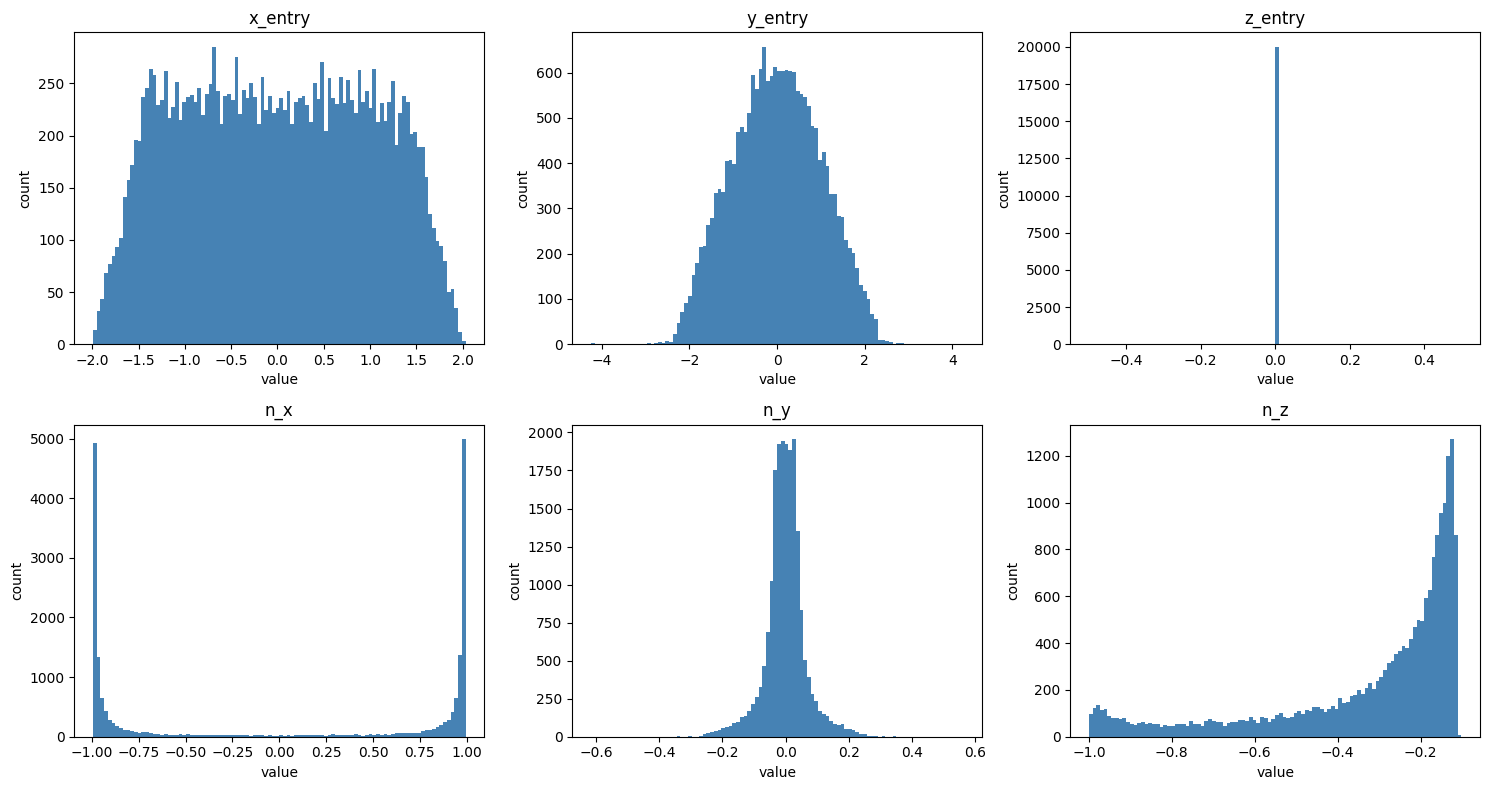

In [5]:
target_names = ['x_entry', 'y_entry', 'z_entry', 'n_x', 'n_y', 'n_z']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, (ax, name) in enumerate(zip(axes.flat, target_names)):
    ax.hist(Y[:, i], bins=100, color='steelblue', edgecolor='none')
    ax.set_title(name)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
plt.tight_layout()
plt.savefig('target_distributions.png')
plt.show()

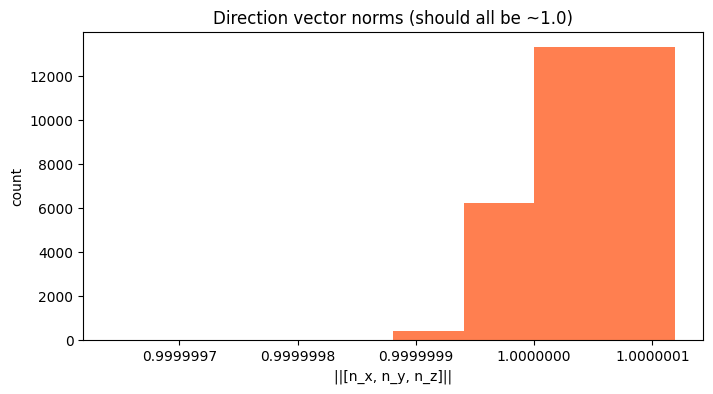

Mean norm: 1.0 Std: 3.98126e-08
Min norm: 0.99999964
Max norm: 1.0000001
Mean norm: 1.0
Std: 3.98126e-08


In [20]:
norms = np.linalg.norm(Y[:, 3:6], axis=1)
plt.figure(figsize=(8, 4))
plt.hist(norms, bins=6, color='coral')
plt.title('Direction vector norms (should all be ~1.0)')
plt.xlabel('||[n_x, n_y, n_z]||')
plt.ylabel('count')
plt.ticklabel_format(useOffset=False)
plt.savefig('direction_norms.png')
plt.show()
print('Mean norm:', norms.mean(), 'Std:', norms.std())

print('Min norm:', norms.min())
print('Max norm:', norms.max())
print('Mean norm:', norms.mean())
print('Std:', norms.std())

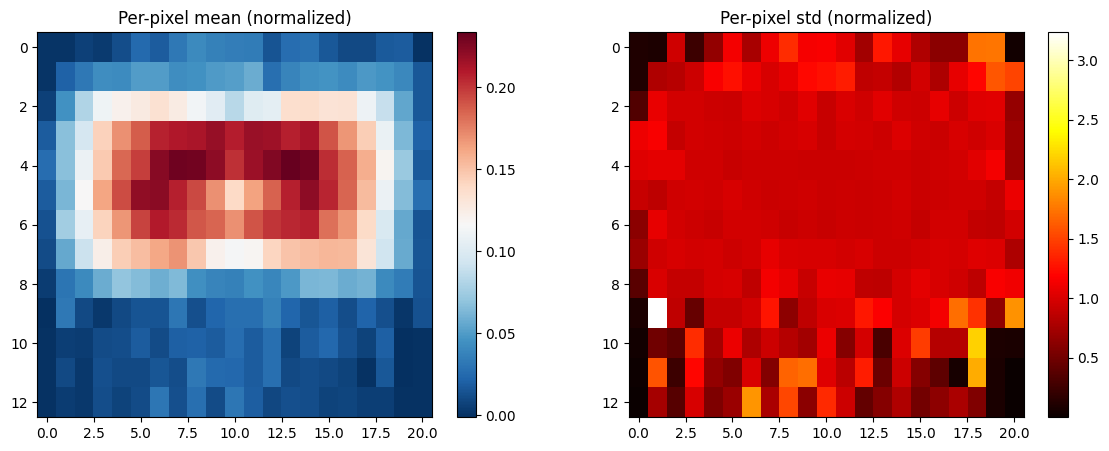

In [21]:
# mean charge per pixel position across all events and timesteps
pixel_mean = X.mean(axis=(0, 1))  # [13, 21]
pixel_std  = X.std(axis=(0, 1))   # [13, 21]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(pixel_mean, cmap='RdBu_r', aspect='auto')
axes[0].set_title('Per-pixel mean (normalized)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(pixel_std, cmap='hot', aspect='auto')
axes[1].set_title('Per-pixel std (normalized)')
plt.colorbar(im1, ax=axes[1])
plt.savefig('pixel_statistics.png')
plt.show()

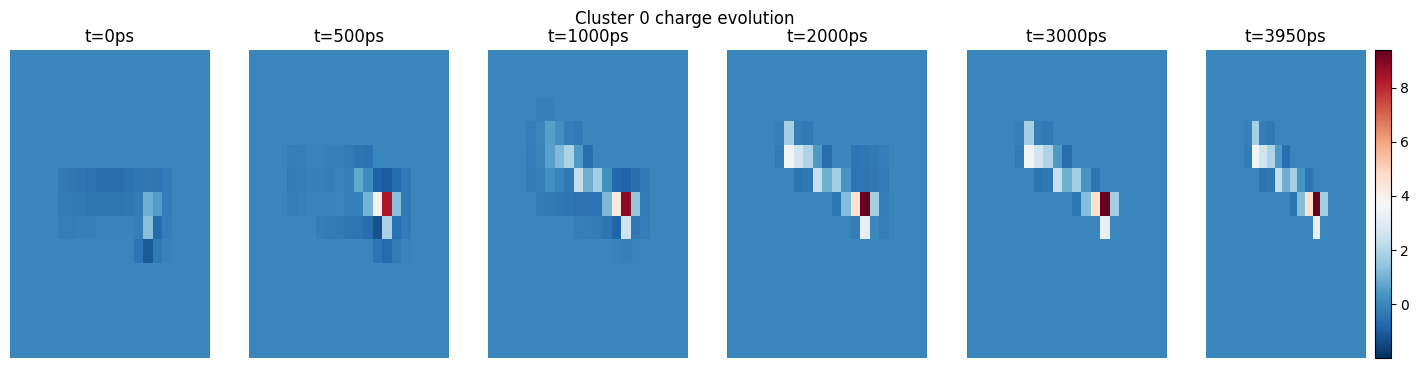

In [22]:
# pick one cluster and show charge at several time steps
sample_idx = 0
sample = X[sample_idx]  # [80, 13, 21]

timesteps = [0, 10, 20, 40, 60, 79]
fig, axes = plt.subplots(1, len(timesteps), figsize=(18, 4))

vmin, vmax = sample.min(), sample.max()
for ax, t in zip(axes, timesteps):
    im = ax.imshow(sample[t], cmap='RdBu_r', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(f't={t*50}ps')
    ax.axis('off')

plt.suptitle(f'Cluster {sample_idx} charge evolution')
plt.colorbar(im, ax=axes[-1])
plt.savefig('charge_evolution.png')
plt.show()

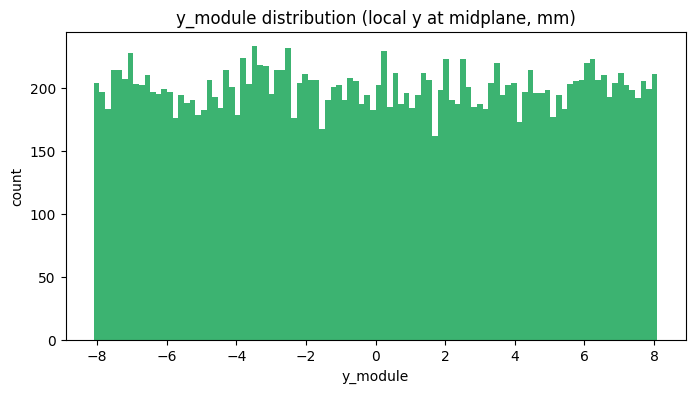

In [23]:
plt.figure(figsize=(8, 4))
plt.hist(y_module, bins=100, color='mediumseagreen')
plt.title('y_module distribution (local y at midplane, mm)')
plt.xlabel('y_module')
plt.ylabel('count')
plt.savefig('ymodule_distribution.png')
plt.show()